# Lab Experiment 6: Comparison of Logistic Regression and K Nearest Neighbors (KNN) Classifiers

**Aim:** Implement Logistic Regression and KNN classifiers on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performance using standard classification metrics.

Dataset used: wdbc.data from the UCI Breast Cancer Wisconsin (Diagnostic) dataset. It has 569 samples, each describing a cell nucleus from a breast mass biopsy, with the diagnosis (malignant or benign) as the target.

---

## 1. Import Libraries

In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score)

## 2. Load the Dataset

wdbc.data has no header row, so the column names need to be added manually. According to wdbc.names, the columns are an id, the diagnosis (M/B), and 30 numeric features. These 30 features are actually just 10 measurements (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension) reported three ways each: mean, standard error, and worst (largest) value.

In [43]:
columns = ['id', 'diagnosis']
features_base = ['radius', 'texture', 'perimeter', 'area', 'smoothness',
                  'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension']
for stat in ['mean', 'se', 'worst']:
    columns += [f'{f}_{stat}' for f in features_base]

df = pd.read_csv('breast+cancer+wisconsin+diagnostic/wdbc.data', header=None, names=columns)
print(df.shape)
df.head()

(569, 32)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 3. Exploratory Data Analysis

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [45]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


The diagnosis column is the target: M means malignant, B means benign. Let's check how the two classes are distributed.

In [46]:
df['diagnosis'].value_counts()

diagnosis
B    357
M    212
Name: count, dtype: int64

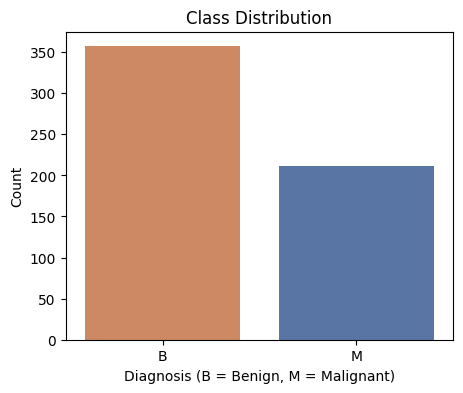

In [47]:
plt.figure(figsize=(5, 4))
sns.countplot(x='diagnosis', hue='diagnosis', data=df, order=['B', 'M'],
              palette=['#4C72B0', '#DD8452'], legend=False)
plt.title('Class Distribution')
plt.xlabel('Diagnosis (B = Benign, M = Malignant)')
plt.ylabel('Count')
plt.show()

357 benign vs 212 malignant, roughly a 63/37 split.

## 4. Check for Missing Values

In [48]:
df.isnull().sum().sum()

np.int64(0)

No missing values, so there is nothing to impute or drop here.

## 5. Preprocessing

Two things need to happen before this data can go into a classifier:
- id is just a row identifier, not a predictive feature, so it gets dropped.
- diagnosis is text (M/B) and needs to be numeric. Mapping it to 1 (malignant) and 0 (benign).

In [49]:
df = df.drop(columns=['id'])
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})
df['diagnosis'].head()

0    1
1    1
2    1
3    1
4    1
Name: diagnosis, dtype: int64

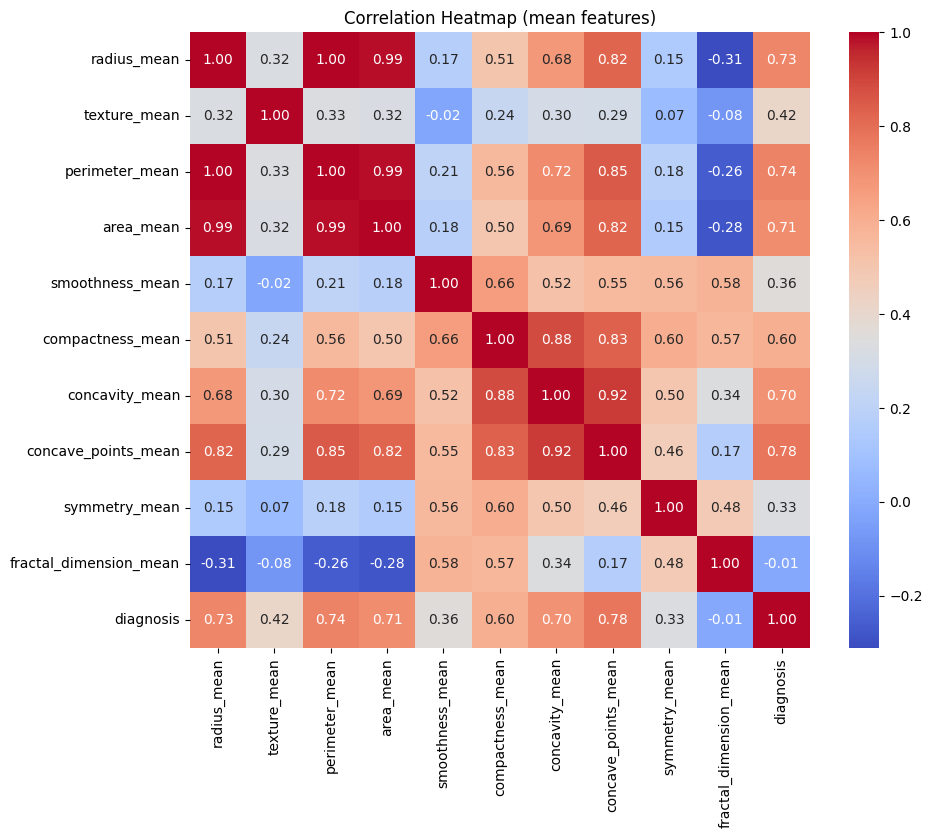

In [50]:
mean_features = [c for c in df.columns if c.endswith('_mean')]
plt.figure(figsize=(10, 8))
sns.heatmap(df[mean_features + ['diagnosis']].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap (mean features)')
plt.show()

Radius, perimeter, area, concavity and concave points are all strongly correlated with diagnosis, and also strongly correlated with each other, which makes sense since they are all essentially describing the size and shape irregularity of the same cell nuclei. No features are dropped for this lab since both models here can handle correlated inputs reasonably well, but this is exactly the kind of thing PCA or manual feature selection would target.

## 6. Feature and Target Split

In [51]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
print(X.shape, y.shape)

(569, 30) (569,)


## 7. Train Test Split

stratify=y is used here so the train and test sets keep roughly the same 63/37 class ratio as the full dataset, instead of a random split possibly skewing one set more than the other.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train size:', X_train.shape[0])
print('Test size:', X_test.shape[0])

Train size: 455
Test size: 114


## 8. Feature Scaling

KNN is a distance based method, so a feature like area (values in the hundreds/thousands) would dominate the distance calculation over a feature like smoothness (values under 1) unless everything is put on the same scale. Logistic Regression is not as sensitive to this, but it still converges faster and cleaner with scaled inputs, so both models use the same scaled data.

The scaler is fit only on the training set and then applied to the test set, so no information from the test set leaks into scaling.

In [53]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 9. Train Logistic Regression

Two versions are trained here: a plain one, and one with class_weight='balanced', which weights the minority (malignant) class more heavily during training to account for the 63/37 split seen earlier. KNN does not have an equivalent parameter (its weights argument controls distance based weighting, not class frequency), so it only gets the one plain version further down.

In [54]:
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train_scaled, y_train)
y_pred_log = log_reg.predict(X_test_scaled)

log_reg_balanced = LogisticRegression(random_state=42, class_weight='balanced')
log_reg_balanced.fit(X_train_scaled, y_train)
y_pred_log_balanced = log_reg_balanced.predict(X_test_scaled)

## 10. Train KNN

Going with the default n_neighbors=5 for this comparison.

In [55]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

## 11. Evaluate the Classifiers

A small helper function is used so the same metrics get printed the same way for all three models instead of repeating the same lines over and over.

In [56]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f'--- {name} ---')
    print(f'Accuracy : {acc:.4f}')
    print(f'Precision: {prec:.4f}')
    print(f'Recall   : {rec:.4f}')
    print(f'F1 Score : {f1:.4f}\n')
    return {'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1 Score': f1}

log_metrics = evaluate('Logistic Regression', y_test, y_pred_log)
log_balanced_metrics = evaluate('Logistic Regression (balanced)', y_test, y_pred_log_balanced)
knn_metrics = evaluate('KNN', y_test, y_pred_knn)

--- Logistic Regression ---
Accuracy : 0.9649
Precision: 0.9750
Recall   : 0.9286
F1 Score : 0.9512

--- Logistic Regression (balanced) ---
Accuracy : 0.9737
Precision: 0.9756
Recall   : 0.9524
F1 Score : 0.9639

--- KNN ---
Accuracy : 0.9561
Precision: 0.9744
Recall   : 0.9048
F1 Score : 0.9383



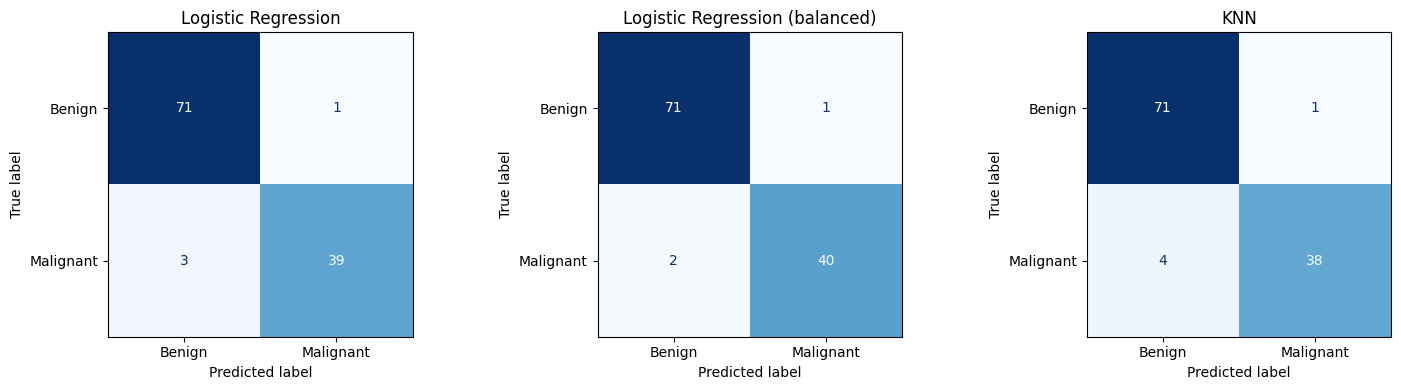

In [57]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log), display_labels=['Benign', 'Malignant']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Logistic Regression')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_log_balanced), display_labels=['Benign', 'Malignant']).plot(
    ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Logistic Regression (balanced)')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn), display_labels=['Benign', 'Malignant']).plot(
    ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('KNN')

plt.tight_layout()
plt.show()

All three only misclassify 1 benign case as malignant, so the real difference between them is on the malignant side, out of 42 malignant cases in the test set: plain Logistic Regression misses 3, the balanced version misses only 2, and KNN misses 4.

In [58]:
comparison_df = pd.DataFrame([log_metrics, log_balanced_metrics, knn_metrics]).set_index('Model')
comparison_df

,Accuracy,Precision,Recall,F1 Score
Model,,,,
Logistic Regression,0.964912,0.975000,0.928571,0.951220
Logistic Regression (balanced),0.973684,0.975610,0.952381,0.963855
KNN,0.956140,0.974359,0.904762,0.938272


Logistic Regression beats KNN on every metric, though the gap is small (about 1 percentage point on accuracy and F1). Recall is the metric to pay the closest attention to in a medical diagnosis setting like this, since a false negative here means a malignant tumor gets called benign, which is the worse mistake to make. Using balanced class weights pushes Logistic Regression's recall up further, from 0.929 to 0.952, and in this case it does so without costing anything on the other metrics, accuracy and F1 both edge up slightly too. That will not always happen (usually there is a small accuracy/precision trade-off for better recall on the minority class), but it shows it is worth at least trying class_weight='balanced' on a dataset like this rather than assuming the default settings are good enough.

## 12. ROC Curve and AUC

The metrics above are all based on the default 0.5 probability cutoff. A ROC curve instead plots true positive rate against false positive rate as that cutoff is varied across its whole range, which gives a fuller picture of how well each model separates the two classes. This needs predicted probabilities rather than hard 0/1 predictions, which both Logistic Regression and KNN provide through predict_proba (for KNN this is just the fraction of the k neighbors that belong to each class).

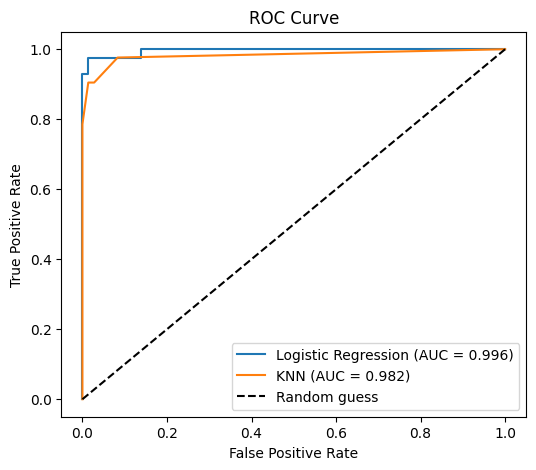

In [59]:
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)

auc_log = roc_auc_score(y_test, y_prob_log)
auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.figure(figsize=(6, 5))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

Logistic Regression gets an AUC of 0.996 against KNN's 0.982. Both are well above the 0.5 line a random guess would give, but Logistic Regression's curve hugs the top left corner more tightly, meaning it separates the two classes better across the full range of thresholds, not just at the default cutoff used above.

## 13. K-Fold Cross Validation

A single train/test split only tells us how the model does on one particular 20% of the data. With 569 rows that split could easily be a bit lucky or unlucky. 5-fold stratified cross validation runs the whole train/evaluate process 5 times on different slices of the data and averages the result, which gives a steadier estimate of how each model actually performs.

Scaling has to happen inside each fold rather than once on the whole dataset, otherwise information from each fold's test portion would leak into the scaler. Wrapping the scaler and model in a pipeline makes cross_val_score handle that correctly.

In [60]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

log_pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(random_state=42))])
knn_pipe = Pipeline([('scaler', StandardScaler()), ('model', KNeighborsClassifier(n_neighbors=5))])

log_cv_scores = cross_val_score(log_pipe, X, y, cv=cv, scoring='accuracy')
knn_cv_scores = cross_val_score(knn_pipe, X, y, cv=cv, scoring='accuracy')

print('Logistic Regression CV Accuracy:', log_cv_scores.round(4), '-> mean', log_cv_scores.mean().round(4))
print('KNN CV Accuracy:', knn_cv_scores.round(4), '-> mean', knn_cv_scores.mean().round(4))

Logistic Regression CV Accuracy: [0.9737 0.9474 0.9649 0.9912 0.9912] -> mean 0.9737
KNN CV Accuracy: [0.9825 0.9474 0.9386 0.9825 0.9646] -> mean 0.9631


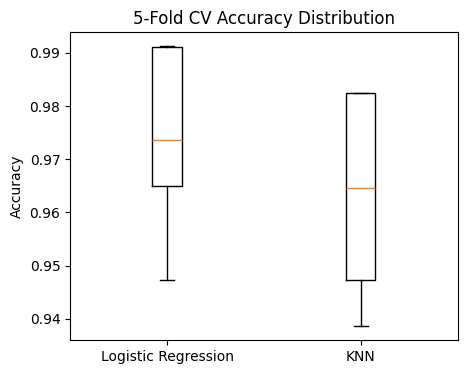

In [61]:
plt.figure(figsize=(5, 4))
plt.boxplot([log_cv_scores, knn_cv_scores], tick_labels=['Logistic Regression', 'KNN'])
plt.ylabel('Accuracy')
plt.title('5-Fold CV Accuracy Distribution')
plt.show()

Logistic Regression averages 0.974 across the 5 folds compared to KNN's 0.963, which lines up with what the single train/test split already suggested. Logistic Regression's fold scores are also a little tighter together (std of about 0.017 vs 0.018 for KNN, and KNN dips as low as 0.939 on one fold), so its performance looks more consistent across different slices of the data, not just better on this one particular split.

## 14. Final Comparison and Conclusion

Putting all the checks together, Logistic Regression comes out on top consistently. On the test set it beats KNN on every metric, and switching to balanced class weights pushes it further still, especially on recall, which is exactly what matters when missing a malignant case is costlier than a false alarm. Looking at all thresholds instead of just one, its ROC AUC of 0.996 also beats KNN's 0.982, and across 5-fold cross validation it keeps averaging higher accuracy (0.974 vs 0.963) while staying more consistent fold to fold.

So Logistic Regression is the better classifier for this dataset, and it wins consistently rather than by a fluke of one particular split. This is not too surprising: the earlier correlation heatmap showed that diagnosis is strongly and fairly linearly related to size/shape features like radius, perimeter, area and concavity, and Logistic Regression is well suited to picking up that kind of relationship directly. KNN has to instead infer the class purely from how close a point is to its neighbors in a 30-dimensional feature space, which gets noisier as the number of features grows, and it does not benefit from the more or less linear separability that this dataset has.

That said, KNN is still doing reasonably well here (over 95% accuracy), just not quite as well or as consistently as Logistic Regression on this dataset.